In [2]:
import pandas as pd

all_years = pd.read_csv('./data/site_species_presence.csv')
# combined = pd.read_csv('./data/site_species_presence_combined.csv')

all_years = all_years[['Unique_ID', 'latitude', 'longitude', 'watershed_area', 'cw_ind', 'pct_dev']]
# combined = combined[['Unique_ID', 'latitude', 'longitude', 'watershed_area', 'cw_ind', 'pct_dev']]

In [3]:
all_3 = all_years[all_years['pct_dev'] <= 3]
all_5 = all_years[all_years['pct_dev'] <= 5]
all_7 = all_years[all_years['pct_dev'] <= 7]
all_10 = all_years[all_years['pct_dev'] <= 10]
all_15 = all_years[all_years['pct_dev'] <= 15]

print("All Years Dataset: 3% development threshold")
print(all_3['cw_ind'].value_counts())
print("\nAll Years Dataset: 5% development threshold")
print(all_5['cw_ind'].value_counts())
print("\nAll Years Dataset: 7% development threshold")
print(all_7['cw_ind'].value_counts())
print("\nAll Years Dataset: 10% development threshold")
print(all_10['cw_ind'].value_counts())
print("\nAll Years Dataset: 15% development threshold")
print(all_15['cw_ind'].value_counts())

All Years Dataset: 3% development threshold
cw_ind
1    159
0     25
Name: count, dtype: int64

All Years Dataset: 5% development threshold
cw_ind
1    211
0     56
Name: count, dtype: int64

All Years Dataset: 7% development threshold
cw_ind
1    245
0     79
Name: count, dtype: int64

All Years Dataset: 10% development threshold
cw_ind
1    260
0     94
Name: count, dtype: int64

All Years Dataset: 15% development threshold
cw_ind
1    270
0    116
Name: count, dtype: int64


In [44]:
comb_3 = combined[combined['pct_dev'] <= 3]
comb_5 = combined[combined['pct_dev'] <= 5]
comb_7 = combined[combined['pct_dev'] <= 7]
comb_10 = combined[combined['pct_dev'] <= 10]
comb_15 = combined[combined['pct_dev'] <= 15]

print("Combined Dataset: 3% development threshold")
print(comb_3['cw_ind'].value_counts())
print("\nCombined Dataset: 5% development threshold")
print(comb_5['cw_ind'].value_counts())
print("\nCombined Dataset: 7% development threshold")
print(comb_7['cw_ind'].value_counts())
print("\nCombined Dataset: 10% development threshold")
print(comb_10['cw_ind'].value_counts())
print("\nCombined Dataset: 15% development threshold")
print(comb_15['cw_ind'].value_counts())

Combined Dataset: 3% development threshold
cw_ind
1    170
0     27
Name: count, dtype: int64

Combined Dataset: 5% development threshold
cw_ind
1    227
0     60
Name: count, dtype: int64

Combined Dataset: 7% development threshold
cw_ind
1    262
0     85
Name: count, dtype: int64

Combined Dataset: 10% development threshold
cw_ind
1    278
0    103
Name: count, dtype: int64

Combined Dataset: 15% development threshold
cw_ind
1    290
0    127
Name: count, dtype: int64


## Subset Selection with Observation Grouping and Stratification

### Approach Explanation and Differences

All-years dataset → GroupShuffleSplit (site-grouped)
                                                                                                                                                       
The all-years data has repeated measurements at the same physical sites across different years (e.g. 01-BKB in 2016, 2019, and 2024). If a naive random split puts the 2016 and 2024 observations of 01-BKB in different folds, the model "sees" that site's watershed area, lat/lon, and species community during training, then gets tested on a near-identical observation — that's leakage. The model appears to generalize well but is really just recognizing sites it already knows. GroupShuffleSplit with site as the group key forces all observations from a given site into either train or test, never both.

Combined dataset → StratifiedShuffleSplit

Each location appears exactly once, so there's no leakage risk. Stratified splitting just ensures each fold preserves the same class ratio (cw_ind=0/1) as the full dataset, which is important because the minority class (0) is small, especially at low thresholds. This gives lower-variance AUC estimates compared to purely random splits.

### Understanding the Output

- Mean AUC Rises w/ More Test Data: Too few training observations - need larger training set.
- Mean AUC rises w/ Less Test Data: Test sets are too small - high variance
- Std AUC is high across the board: Dataset is too small / imbalanced
- Goal is to find where Mean AUC peaks in the middle (bias/variance tradeoff)

### Using Findings
- Attempt to balance high mean AUC with an acceptable Std AUC.
- For a threshold use the decided on test/train split for model training
- Importantly, low thresholds have the present class much larger than the absent class and will have a misleading AUC. If using very imbalanced P/A classes, add class_weight='balanced' to LogisticRegression. (Likely improve AUC, may hurt precision aka false positives)
- Use lr.coef_ to show what fish help predict cw_ind best (if using fish). 


In [4]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Extract the site ID from Unique_ID — format is SITE_month_day_year,
# so strip the last 3 underscore-separated tokens to get the site key.
# This ensures the same physical location never appears in both train and test.
def extract_site_id(uid):
    parts = uid.split('_')
    return '_'.join(parts[:-3])

def evaluate_split_ratios(df, name, test_sizes=None, n_splits=30, random_state=42):
    if test_sizes is None:
        test_sizes = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]

    feature_cols = [c for c in df.columns if c not in ['Unique_ID', 'cw_ind', 'pct_dev']]
    X = df[feature_cols].values
    y = df['cw_ind'].values
    groups = df['Unique_ID'].apply(extract_site_id).values

    n_sites = len(np.unique(groups))
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    results = {}
    for test_size in test_sizes:
        gss = GroupShuffleSplit(n_splits=n_splits, test_size=test_size, random_state=random_state)
        aucs = []
        for train_idx, test_idx in gss.split(X_scaled, y, groups):
            X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            # Skip folds where a split yields only one class
            if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
                continue

            lr = LogisticRegression(max_iter=1000, random_state=random_state, class_weight='balanced')
            lr.fit(X_train, y_train)
            y_prob = lr.predict_proba(X_test)[:, 1]
            aucs.append(roc_auc_score(y_test, y_prob))

        if aucs:
            results[test_size] = {
                'mean_auc': np.mean(aucs),
                'std_auc':  np.std(aucs),
                'n_valid':  len(aucs),
            }

    best_size = max(results, key=lambda k: results[k]['mean_auc'])
    best_auc  = results[best_size]['mean_auc']

    class_counts = dict(zip(*np.unique(y, return_counts=True)))
    print(f"\n{'='*62}")
    print(f"Dataset : {name}")
    print(f"Obs     : {len(df)}   |   Sites (groups): {n_sites}")
    print(f"Classes : cw_ind=0 → {class_counts.get(0,0)}   cw_ind=1 → {class_counts.get(1,0)}")
    print(f"{'Test %':>10} {'Train %':>9} {'Mean AUC':>10} {'Std AUC':>9} {'Splits':>8}")
    print('-'*50)
    for ts, res in results.items():
        marker = ' *' if ts == best_size else ''
        print(f"{ts:>10.0%} {1-ts:>9.0%} {res['mean_auc']:>10.4f} "
              f"{res['std_auc']:>9.4f} {res['n_valid']:>8}{marker}")
    print(f"\n  Best: test_size={best_size:.0%}  (Mean AUC = {best_auc:.4f})")

    return results, best_size

datasets = [
    ('pct_dev ≤ 3%',  all_3),
    ('pct_dev ≤ 5%',  all_5),
    ('pct_dev ≤ 7%',  all_7),
    ('pct_dev ≤ 10%', all_10),
    ('pct_dev ≤ 15%', all_15),
]

best_splits = {}
for name, df in datasets:
    results, best_size = evaluate_split_ratios(df, name)
    best_splits[name] = best_size

print("\n" + "="*62)
print("SUMMARY — Best Train/Test Split per Development Threshold")
print("="*62)
for name, best_size in best_splits.items():
    print(f"  {name:<16}  test={best_size:.0%}  /  train={1-best_size:.0%}")


ValueError: could not convert string to float: '00E-PGS_7_22_2021'

In [9]:
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Combined datasets have unique locations, so no site-grouping is needed.
# StratifiedShuffleSplit is used instead to preserve class ratios in each fold.
def evaluate_split_ratios_combined(df, name, test_sizes=None, n_splits=30, random_state=42):
    if test_sizes is None:
        test_sizes = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]

    feature_cols = [c for c in df.columns if c not in ['Unique_ID', 'cw_ind', 'pct_dev', 'EMDStationID_Current']]
    X = df[feature_cols].values
    y = df['cw_ind'].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    results = {}
    for test_size in test_sizes:
        sss = StratifiedShuffleSplit(n_splits=n_splits, test_size=test_size, random_state=random_state)
        aucs = []
        for train_idx, test_idx in sss.split(X_scaled, y):
            X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            lr = LogisticRegression(max_iter=1000, random_state=random_state)
            lr.fit(X_train, y_train)
            y_prob = lr.predict_proba(X_test)[:, 1]
            aucs.append(roc_auc_score(y_test, y_prob))

        results[test_size] = {
            'mean_auc': np.mean(aucs),
            'std_auc':  np.std(aucs),
            'n_valid':  len(aucs),
        }

    best_size = max(results, key=lambda k: results[k]['mean_auc'])
    best_auc  = results[best_size]['mean_auc']

    class_counts = dict(zip(*np.unique(y, return_counts=True)))
    print(f"\n{'='*62}")
    print(f"Dataset : {name}")
    print(f"Obs     : {len(df)}")
    print(f"Classes : cw_ind=0 → {class_counts.get(0,0)}   cw_ind=1 → {class_counts.get(1,0)}")
    print(f"{'Test %':>10} {'Train %':>9} {'Mean AUC':>10} {'Std AUC':>9} {'Splits':>8}")
    print('-'*50)
    for ts, res in results.items():
        marker = ' *' if ts == best_size else ''
        print(f"{ts:>10.0%} {1-ts:>9.0%} {res['mean_auc']:>10.4f} "
              f"{res['std_auc']:>9.4f} {res['n_valid']:>8}{marker}")
    print(f"\n  Best: test_size={best_size:.0%}  (Mean AUC = {best_auc:.4f})")

    return results, best_size

datasets = [
    ('pct_dev ≤ 3%',  all_3),
    ('pct_dev ≤ 5%',  all_5),
    ('pct_dev ≤ 7%',  all_7),
    ('pct_dev ≤ 10%', all_10),
    ('pct_dev ≤ 15%', all_15),
]

best_splits_combined = {}
for name, df in datasets:
    results, best_size = evaluate_split_ratios_combined(df, name)
    best_splits_combined[name] = best_size

print("\n" + "="*62)
print("SUMMARY — Best Train/Test Split per Development Threshold (Combined)")
print("="*62)
for name, best_size in best_splits_combined.items():
    print(f"  {name:<26}  test={best_size:.0%}  /  train={1-best_size:.0%}")



Dataset : pct_dev ≤ 3%
Obs     : 184
Classes : cw_ind=0 → 25   cw_ind=1 → 159
    Test %   Train %   Mean AUC   Std AUC   Splits
--------------------------------------------------
       10%       90%     0.7854    0.1835       30
       15%       85%     0.7872    0.1204       30 *
       20%       80%     0.7560    0.1172       30
       25%       75%     0.7735    0.1200       30
       30%       70%     0.7666    0.0945       30
       35%       65%     0.7694    0.0511       30
       40%       60%     0.7566    0.0859       30

  Best: test_size=15%  (Mean AUC = 0.7872)

Dataset : pct_dev ≤ 5%
Obs     : 267
Classes : cw_ind=0 → 56   cw_ind=1 → 211
    Test %   Train %   Mean AUC   Std AUC   Splits
--------------------------------------------------
       10%       90%     0.7741    0.1035       30
       15%       85%     0.7714    0.0774       30
       20%       80%     0.7610    0.0835       30
       25%       75%     0.7803    0.0699       30 *
       30%       70%     0.75

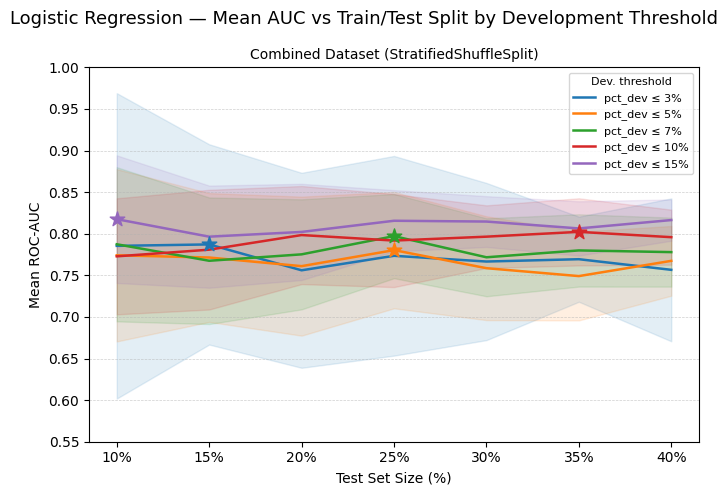

In [10]:
import io, contextlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

test_sizes = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]
colors     = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
labels     = ['3%', '5%', '7%', '10%', '15%']

comb_results = {}

with contextlib.redirect_stdout(io.StringIO()):
    for name, df in datasets:
        r, _ = evaluate_split_ratios_combined(df, name)
        comb_results[name] = r

x = [ts * 100 for ts in test_sizes]

fig, ax = plt.subplots(figsize=(7, 5))
fig.suptitle('Logistic Regression — Mean AUC vs Train/Test Split by Development Threshold', fontsize=13)

for (name, res), color, label in zip(comb_results.items(), colors, labels):
    means = [res[ts]['mean_auc'] for ts in test_sizes]
    stds  = [res[ts]['std_auc']  for ts in test_sizes]
    best  = max(test_sizes, key=lambda ts: res[ts]['mean_auc'])

    ax.plot(x, means, color=color, linewidth=1.8, label=f'pct_dev ≤ {label}')
    ax.fill_between(
        x,
        [m - s for m, s in zip(means, stds)],
        [m + s for m, s in zip(means, stds)],
        color=color, alpha=0.12,
    )
    ax.scatter(
        [best * 100], [res[best]['mean_auc']],
        color=color, marker='*', s=120, zorder=5,
    )

ax.set_title('Combined Dataset (StratifiedShuffleSplit)', fontsize=10)
ax.set_xlabel('Test Set Size (%)')
ax.set_ylabel('Mean ROC-AUC')
ax.set_xticks(x)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
ax.set_ylim(0.55, 1.0)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.legend(fontsize=8, title='Dev. threshold', title_fontsize=8)
ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.6)

plt.tight_layout()
plt.show()

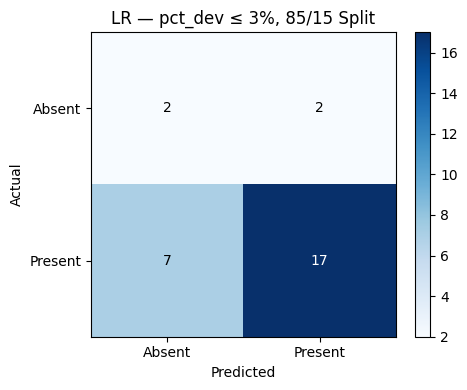

Accuracy: 0.68
Precision: 0.89
Recall: 0.71
F1 Score: 0.79

--- Logistic Regression Equation ---
log(p / (1-p)) = +0.4497
  +1.1470 × latitude
  +0.0024 × longitude
  -0.2685 × watershed_area

--- Training Set Sites (156 unique IDs) ---
['00B-PDB_9_14_2023', '00D-BRB_6_30_2022', '00D-CORS_8_23_2019', '00E-PGS_7_22_2021', '00L-OTT_7_20_2016', '01-ATW_10_12_2023', '01-BBW_7_24_2003', '01-BEN_6_24_2005', '01-BGK_8_5_2019', '01-BIS_7_19_2023', '01-BLA_6_15_2023', '01-BRB_9_30_2024', '01-CNB_8_21_2019', '01-CNY_7_19_2023', '01-CUB_7_11_2016', '01-GSB_9_28_2015', '01-IND_7_25_2023', '01-LMB_7_31_2002', '01-SBRN_10_4_2023', '01-SMO_9_22_2023', '01-STW_9_3_2024', '01-TAY_8_14_2002', '01-TYB_6_21_2022', '01-UNF_7_29_2002', '01-WIR_7_20_2016', '01-WISE_10_12_2023', '01-WLK_6_29_2022', '01-XD3_7_30_2015', '01A-EMB_9_18_2023', '01D-X2BKW_7_17_2024', '01G-NAS_7_31_2002', '01J-MLB_8_3_2004', '01M-CHU_7_11_2002', '01M-INS_7_23_2003', '01M-PGS_7_10_2003', '01M-X1BKW_10_1_2024', '01W-PAU_7_24_2024', '0

In [17]:
import sys, io, json, os, contextlib
import numpy as np
sys.path.append('./utils')
from utils.confusion import classification_report_suite
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

THRESHOLD = 3 # Adjust to what pct_dev threshold you want to test (e.g., 3, 5, 7, 10, 15)
TEST_SPLIT = 0.15 # Adjust to the test size you want to use (e.g., 0.10, 0.15, 0.20, etc.)

df = switch = {
    3: all_3,
    5: all_5,
    7: all_7,
    10: all_10,
    15: all_15,
}.get(THRESHOLD, all_10) # Default to all_10 if threshold is not in the dict

feature_cols = [c for c in df.columns if c not in ['Unique_ID', 'cw_ind', 'pct_dev', 'EMDStationID_Current']]
X = df[feature_cols].values
y = df['cw_ind'].values

indices = np.arange(len(df))
train_idx, test_idx = train_test_split(indices, test_size=TEST_SPLIT, random_state=42, stratify=y)
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)

intercept = lr.intercept_[0]
coefs = lr.coef_[0]
train_ids = sorted(df['Unique_ID'].iloc[train_idx].unique().tolist())
test_ids  = sorted(df['Unique_ID'].iloc[test_idx].unique().tolist())

buffer = io.StringIO()
with contextlib.redirect_stdout(buffer):
    classification_report_suite(y_test, y_pred, labels=['Absent', 'Present'], title=f'LR — pct_dev ≤ {THRESHOLD}%, {int((1 - TEST_SPLIT) * 100)}/{int(TEST_SPLIT * 100)} Split')

    print("\n--- Logistic Regression Equation ---")
    print(f"log(p / (1-p)) = {intercept:+.4f}")
    for feat, coef in zip(feature_cols, coefs):
        print(f"  {coef:+.4f} × {feat}")

    print(f"\n--- Training Set Sites ({len(train_ids)} unique IDs) ---")
    print(train_ids)
    print(f"\n--- Test Set Sites ({len(test_ids)} unique IDs) ---")
    print(test_ids)

output_text = buffer.getvalue()
print(output_text)

os.makedirs('./output', exist_ok=True)
output_path = f'./output/lr_pct{THRESHOLD}_split{int(TEST_SPLIT * 100)}.json'
with open(output_path, 'w') as f:
    json.dump({
        'model': 'logistic_regression',
        'threshold': THRESHOLD,
        'test_split': TEST_SPLIT,
        'output': output_text.splitlines(),
    }, f, indent=2)
print(f"Output saved to {output_path}")
